# Random Forest (BoW)

## Config Setup

### 1. Import Libraries + Setup

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

from src.dataloader import DataLoader
from models.decision_trees.random_forest import RandomForestModel
from helpers.save_model_params import extract_rf_to_dict

# Configs
pickle_path = '../models/decision_trees/fitted_bow_rf.pkl'
train_data_path = '../src/data/train_data.csv'
val_data_path = '../src/data/validation_data.csv'
test_data_path = '../src/data/test_data.csv'
random_seed = 42

hyperparams = {
    "random_state": random_seed,
    "n_estimators": [100, 200, 500, 1000],
    "max_features": ['sqrt', 'log2'],
    "max_depth": [5, 10, 15, 20, 25, 30],
    "min_samples_split": [2, 4, 8, 16],
    "min_samples_leaf": [1, 5, 10],
    "criterion": ["gini", "entropy"],
}

### 2. Generate Training and Validation Data (BoW)

In [3]:
dataloader = DataLoader(random_seed)
X_train, y_train = dataloader.generate_Xt(train_data_path)
X_val, y_val = dataloader.generate_Xt(val_data_path)

### 3. Functions to plot Random Forests as they are generated

In [34]:
def plot_hyperparameter_effects(df, hyperparams, best_params):
    """Create plots showing how each hyperparameter affects validation accuracy"""
    
    # Determine number of hyperparameters to plot
    # Only include parameters that are actually in the DataFrame
    param_names = [p for p in hyperparams.keys() if p in df.columns]
    n_params = len(param_names)
    
    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, param in enumerate(param_names):
        ax = axes[idx]
        
        # Group by parameter and calculate mean accuracy
        grouped = df.groupby(param)['accuracy'].agg(['mean', 'std', 'max'])
        
        # Plot
        x_values = grouped.index
        ax.plot(x_values, grouped['mean'], marker='o', linewidth=2, markersize=8, label='Mean Accuracy')
        ax.fill_between(x_values, 
                        grouped['mean'] - grouped['std'], 
                        grouped['mean'] + grouped['std'], 
                        alpha=0.3, label='±1 Std Dev')
        ax.scatter(x_values, grouped['max'], color='red', marker='*', s=150, 
                  label='Max Accuracy', zorder=5)
        
        # Highlight best parameter value
        if param in best_params and best_params[param] in x_values:
            best_val = best_params[param]
            best_acc = grouped.loc[best_val, 'mean']
            ax.axvline(best_val, color='green', linestyle='--', alpha=0.7, 
                      linewidth=2, label=f'Best: {best_val}')
        
        ax.set_xlabel(param, fontsize=12, fontweight='bold')
        ax.set_ylabel('Validation Accuracy', fontsize=12)
        ax.set_title(f'Effect of {param}', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        
        # Format x-axis for better readability
        if isinstance(x_values[0], (int, float)):
            ax.set_xticks(x_values)
    
    # Remove extra subplots if any
    for idx in range(n_params, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.suptitle('Hyperparameter Effects on Validation Accuracy', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.show()
    
    # Additional plot: Top 20 configurations
    plot_top_configurations(df, top_n=20)


def plot_top_configurations(df, top_n=20):
    """Plot the top N configurations"""
    
    top_configs = df.nlargest(top_n, 'accuracy').reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    x = np.arange(len(top_configs))
    bars = ax.bar(x, top_configs['accuracy'], color='steelblue', alpha=0.7)
    
    # Highlight the best configuration
    bars[0].set_color('gold')
    bars[0].set_edgecolor('darkgoldenrod')
    bars[0].set_linewidth(2)
    
    ax.set_xlabel('Configuration Rank', fontsize=12, fontweight='bold')
    ax.set_ylabel('Validation Accuracy', fontsize=12, fontweight='bold')
    ax.set_title(f'Top {top_n} Hyperparameter Configurations', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'#{i+1}' for i in range(len(top_configs))])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add accuracy values on top of bars
    for i, (idx, row) in enumerate(top_configs.iterrows()):
        ax.text(i, row['accuracy'] + 0.001, f'{row["accuracy"]:.4f}', 
               ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print top 5 configurations details
    print("\n" + "="*80)
    print("TOP 5 CONFIGURATIONS:")
    print("="*80)
    for i, (idx, row) in enumerate(top_configs.head(5).iterrows()):
        print(f"\n#{i+1} - Accuracy: {row['accuracy']:.4f}")
        print(f"  n_estimators: {row['n_estimators']}, max_features: {row['max_features']}, "
              f"max_depth: {row['max_depth']}")
        print(f"  min_samples_split: {row['min_samples_split']}, "
              f"min_samples_leaf: {row['min_samples_leaf']}, criterion: {row['criterion']}")



### 4. Function to generate Fitted Random Forests w/ hyperparameter permutations

In [29]:
def search_hyperparameters(X_train, y_train, X_val, y_val, hyperparams, random_seed=42):
    best_acc = 0.0
    best_params = {}
    results = []

    for n_estimators in hyperparams["n_estimators"]:
        for max_features in hyperparams["max_features"]:
            for max_depth in hyperparams["max_depth"]:
                for min_samples_split in hyperparams["min_samples_split"]:
                    for min_samples_leaf in hyperparams["min_samples_leaf"]:
                        for criterion in hyperparams["criterion"]:
                            model = RandomForestClassifier(
                                n_estimators=n_estimators,
                                max_features=max_features,
                                max_depth=max_depth,
                                min_samples_split=min_samples_split,
                                min_samples_leaf=min_samples_leaf,
                                criterion=criterion,
                                random_state=random_seed
                            )
                            model.fit(X_train, y_train)
                            y_val_pred = model.predict(X_val)
                            val_accuracy = accuracy_score(y_val, y_val_pred)

                            # Store results
                            results.append({
                                "n_estimators": n_estimators,
                                "max_features": max_features,
                                "max_depth": max_depth,
                                "min_samples_split": min_samples_split,
                                "min_samples_leaf": min_samples_leaf,
                                "criterion": criterion,
                                "accuracy": val_accuracy
                            })

                            if val_accuracy > best_acc:
                                best_acc = val_accuracy
                                best_params = {
                                    "n_estimators": n_estimators,
                                    "max_features": max_features,
                                    "max_depth": max_depth,
                                    "min_samples_split": min_samples_split,
                                    "min_samples_leaf": min_samples_leaf,
                                    "criterion": criterion
                                }

                            print(f"Params: n_estimators={n_estimators}, max_features={max_features}, "
                                  f"max_depth={max_depth}, min_samples_split={min_samples_split}, "
                                  f"min_samples_leaf={min_samples_leaf}, criterion={criterion}, "
                                  f"\n\t => Validation Accuracy: {val_accuracy:.4f}")

    # Create visualizations
    df = pd.DataFrame(results)
    # plot_hyperparameter_effects(df, hyperparams, best_params)
    
    return best_params, df

## Find Best Random Forest

### 1. Find best hyperparameter permutations

In [32]:
best_hyperparams, df = search_hyperparameters(X_train, y_train, X_val, y_val, hyperparams, random_seed)
print("Best Hyperparameters:")
for param, value in best_hyperparams.items():
    print(f"{param}: {value}")

/home/tshafiq/.local/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Params: n_estimators=100, max_features=sqrt, max_depth=5, min_samples_split=2, min_samples_leaf=1, criterion=gini, 
	 => Validation Accuracy: 0.7600


/home/tshafiq/.local/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Params: n_estimators=100, max_features=sqrt, max_depth=5, min_samples_split=2, min_samples_leaf=1, criterion=entropy, 
	 => Validation Accuracy: 0.7667


/home/tshafiq/.local/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


...

Params: n_estimators=1000, max_features=log2, max_depth=30, min_samples_split=16, min_samples_leaf=5, criterion=entropy, 
	 => Validation Accuracy: 0.7400


/home/tshafiq/.local/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Params: n_estimators=1000, max_features=log2, max_depth=30, min_samples_split=16, min_samples_leaf=10, criterion=gini, 
	 => Validation Accuracy: 0.6867


/home/tshafiq/.local/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Params: n_estimators=1000, max_features=log2, max_depth=30, min_samples_split=16, min_samples_leaf=10, criterion=entropy, 
	 => Validation Accuracy: 0.6933
Best Hyperparameters:
n_estimators: 500
max_features: log2
max_depth: 25
min_samples_split: 2
min_samples_leaf: 1
criterion: gini


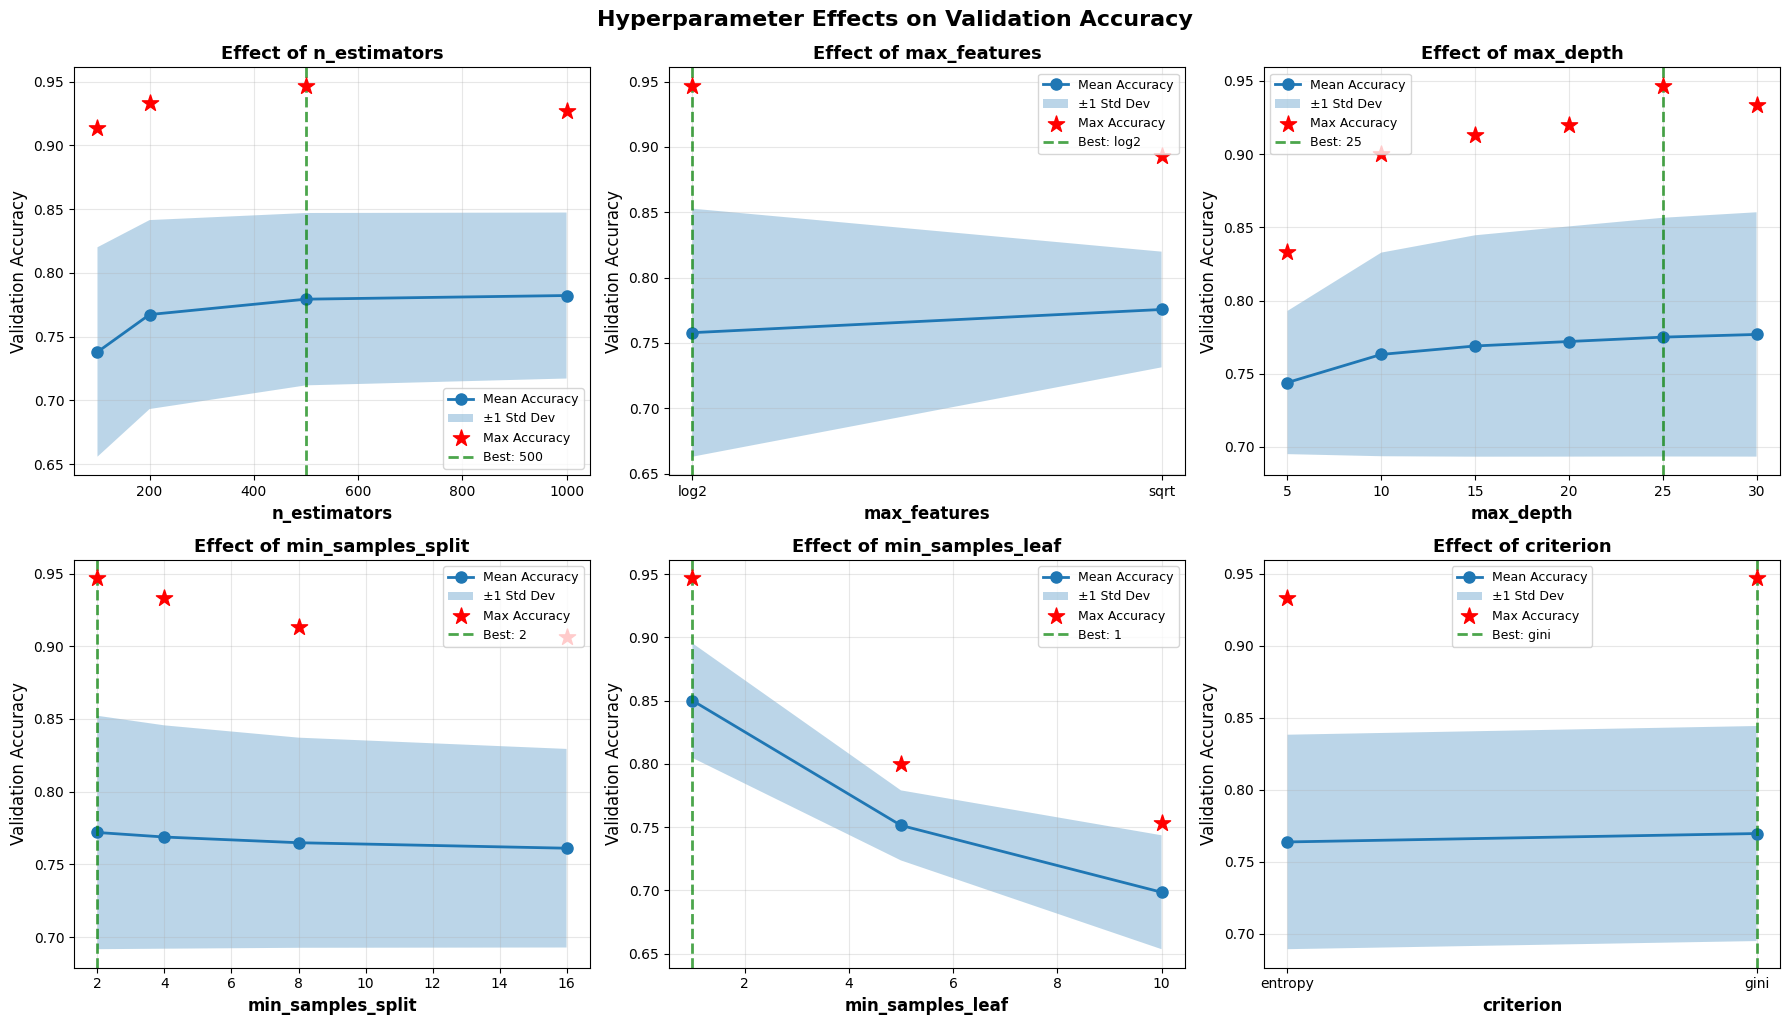

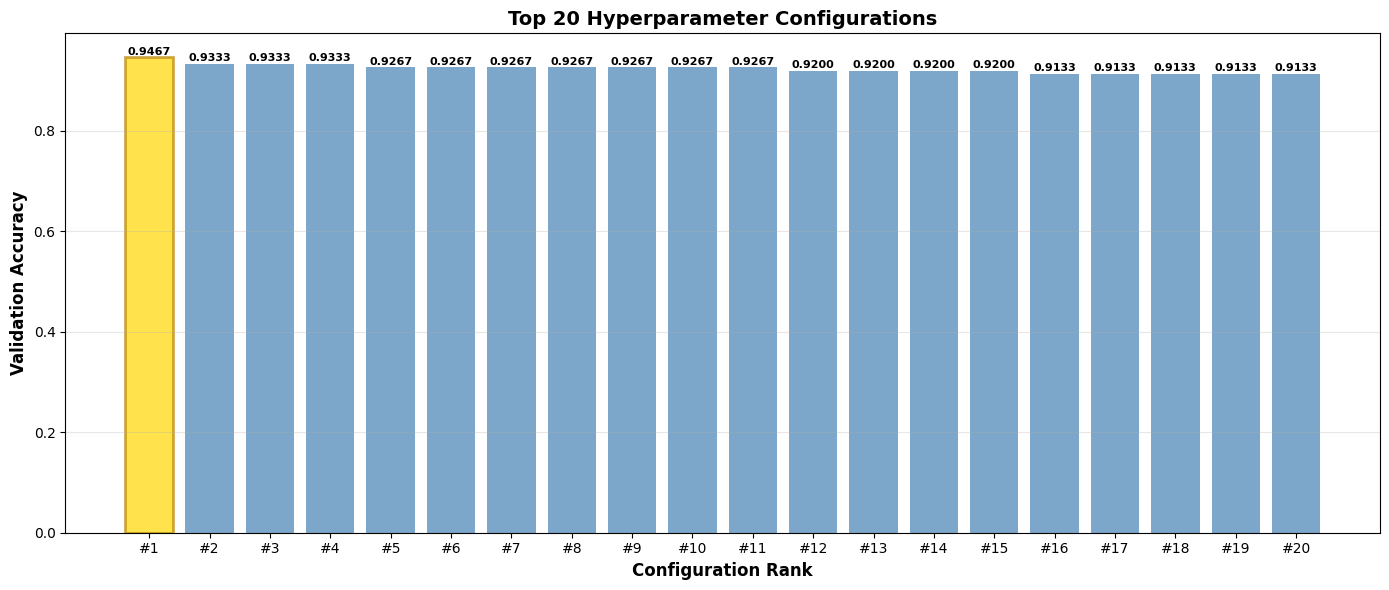


TOP 5 CONFIGURATIONS:

#1 - Accuracy: 0.9467
  n_estimators: 500, max_features: log2, max_depth: 25
  min_samples_split: 2, min_samples_leaf: 1, criterion: gini

#2 - Accuracy: 0.9333
  n_estimators: 200, max_features: log2, max_depth: 30
  min_samples_split: 2, min_samples_leaf: 1, criterion: entropy

#3 - Accuracy: 0.9333
  n_estimators: 500, max_features: log2, max_depth: 30
  min_samples_split: 2, min_samples_leaf: 1, criterion: entropy

#4 - Accuracy: 0.9333
  n_estimators: 500, max_features: log2, max_depth: 30
  min_samples_split: 4, min_samples_leaf: 1, criterion: gini

#5 - Accuracy: 0.9267
  n_estimators: 500, max_features: log2, max_depth: 25
  min_samples_split: 2, min_samples_leaf: 1, criterion: entropy


In [35]:
plot_hyperparameter_effects(df, hyperparams, best_hyperparams)

## Generate Best Random Forest w/ Best Hyperparameters and Save Splits to JSON

### 1. Generate Random Forest w/ Best Hyperparameters

In [8]:
# Best Hyperparams: {'n_estimators': 500, 'max_features': 'log2', 'max_depth': 25, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'gini'}

best_hyperparams = {'n_estimators': 200, 'max_features': 'log2', 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'entropy'}

sklearn_rf = RandomForestClassifier(
    n_estimators=best_hyperparams["n_estimators"],
    max_features=best_hyperparams["max_features"],
    max_depth=best_hyperparams["max_depth"],
    criterion=best_hyperparams["criterion"],
    min_samples_split=best_hyperparams["min_samples_split"],
    min_samples_leaf=best_hyperparams["min_samples_leaf"],
    random_state=random_seed
)

sklearn_rf.fit(X_train, y_train)

y_pred_val = sklearn_rf.predict(X_val)
y_pred_train = sklearn_rf.predict(X_train)
val_accuracy = accuracy_score(y_val, y_pred_val)
train_accuracy = accuracy_score(y_train, y_pred_train)

print(f"Best Hyperparams: {best_hyperparams}")
print(f"Validation Accuracy: {val_accuracy:.4f}\n Training Accuracy: {train_accuracy:.4f}")

/home/tshafiq/.local/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best Hyperparams: {'n_estimators': 200, 'max_features': 'log2', 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'entropy'}
Validation Accuracy: 0.9333
 Training Accuracy: 0.9907


### 2. Extract splits to JSON

In [9]:
# rf_dict = extract_rf_to_dict(sklearn_rf)

with open(pickle_path, 'wb') as f:
    pickle.dump(sklearn_rf, f)
    
print(f"Random forest saved to: {pickle_path}")

Random forest saved to: ../models/decision_trees/fitted_bow_rf.pkl


## Verify Correct Random Forest Saved Correctly

### 1. Build saved Random Forest from JSON

In [10]:
with open(pickle_path, 'rb') as f:
    custom_rf = pickle.load(f)

### 2. Generate Predictions from Extracted Splits and Verify Predictions Made

In [11]:
sklearn_train_preds = sklearn_rf.predict(X_train)
custom_train_preds = custom_rf.predict(X_train.to_numpy())

sklearn_val_predictions = sklearn_rf.predict(X_val)
custom_val_predictions = custom_rf.predict(X_val.to_numpy())

train_matches = np.sum(sklearn_train_preds == custom_train_preds)
train_total = len(X_train)

val_matches = np.sum(sklearn_val_predictions == custom_val_predictions)
val_total = len(X_val)

print(f"Training Predictions match: {train_matches}/{train_total}")
print(f"\nsklearn training accuracy: {accuracy_score(y_train, sklearn_train_preds):.4f}")
print(f"Custom training accuracy: {accuracy_score(y_train, custom_train_preds):.4f}\n")

print(f"Validation Predictions match: {val_matches}/{val_total}")
print(f"\nsklearn validation accuracy: {accuracy_score(y_val, sklearn_val_predictions):.4f}")
print(f"Custom validation accuracy: {accuracy_score(y_val, custom_val_predictions):.4f}")

Training Predictions match: 648/648

sklearn training accuracy: 0.9907
Custom training accuracy: 0.9907

Validation Predictions match: 150/150

sklearn validation accuracy: 0.9333
Custom validation accuracy: 0.9333


/home/tshafiq/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/tshafiq/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
